# Stage 3 Localisation Pretraining on 140k Aligned Faces
This notebook presents the pretraining stage of the semantic-region localisation model on the 140k aligned face dataset. The model learns both image-level fake/real classification and region-level manipulation evidence using semantic facial masks.

Unlike the non-localisation Stage 3 notebook, this version includes semantic region supervision and qualitative localisation analysis.


## 1. Import Libraries and Set Up Environment
This section imports the libraries required for data loading, augmentation, model training, evaluation, and localisation visualisation.


In [1]:
import os, random, warnings
from io import BytesIO
from pathlib import Path

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import torchvision.transforms.functional as TF

from tqdm import tqdm
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings("ignore")

## 2. Dataset Paths
This section defines the aligned 140k image dataset and the corresponding precomputed semantic face masks used during pretraining.


In [2]:
IMG_ROOT = "/kaggle/input/datasets/hooriyamasood80/140k-faces-aligned/kaggle/working/140k_aligned_faces"
MASK_ROOT = "/kaggle/input/datasets/hooriyamasood80/140k-semantic-masks-20-regions/kaggle/working/140k_semantic_masks_20"  

## 3. Augmentation, Metrics, Helper Functions, and Model Definition
This section defines:
- JPEG-based augmentation
- DeepfakeBench-style metrics
- semantic mask pooling utilities
- the MIL region loss
- the semantic-region localisation model used for pretraining


In [3]:
class RandomJPEG:
    def __init__(self, quality_min=30, quality_max=100, p=0.7):
        self.quality_min = quality_min
        self.quality_max = quality_max
        self.p = p

    def __call__(self, img: Image.Image):
        if random.random() > self.p:
            return img
        q = random.randint(self.quality_min, self.quality_max)
        buf = BytesIO()
        img.save(buf, format="JPEG", quality=q)
        buf.seek(0)
        return Image.open(buf).convert("RGB")

In [4]:
class DualViewMaskImageFolder(datasets.ImageFolder):
    def __init__(self, img_root, mask_root, p_flip=0.5, jpeg_aug=None, rgb_color_aug=None, rgb_norm=None):
        super().__init__(img_root, transform=None)
        self.img_root = Path(img_root)
        self.mask_root = Path(mask_root)
        self.p_flip = p_flip
        self.jpeg_aug = jpeg_aug
        self.rgb_color_aug = rgb_color_aug
        self.rgb_norm = rgb_norm

    def __getitem__(self, index):
        path, y = self.samples[index]
        img_path = Path(path)

        rel = img_path.relative_to(self.img_root)
        mask_path = self.mask_root / rel.parent / (img_path.stem + ".npz")

        img = self.loader(path).convert("RGB")
        masks = np.load(mask_path)["masks"].astype(np.float32) / 255.0
        

        do_flip = random.random() < self.p_flip
        if do_flip:
            img = TF.hflip(img)
            masks = np.flip(masks, axis=2).copy()

            swap_pairs = [
                (1, 3),    # forehead_left <-> forehead_right
                (4, 5),    # left_eye <-> right_eye
                (6, 7),    # left_eyebrow <-> right_eyebrow
                (10, 11),  # left_under_eye <-> right_under_eye
                (12, 13),  # left_cheek_upper <-> right_cheek_upper
                (14, 15),  # left_cheek_lower <-> right_cheek_lower
            ]
            
            for a, b in swap_pairs:
                masks[[a, b]] = masks[[b, a]]

        if self.jpeg_aug is not None:
            img_jpeg = self.jpeg_aug(img)
        else:
            img_jpeg = img

        x_raw = TF.to_tensor(img_jpeg)

        img_rgb = img_jpeg
        if self.rgb_color_aug is not None:
            img_rgb = self.rgb_color_aug(img_rgb)

        x_rgb = TF.to_tensor(img_rgb)
        if self.rgb_norm is not None:
            x_rgb = self.rgb_norm(x_rgb)

        masks_t = torch.tensor(masks, dtype=torch.float32)

        return x_rgb, x_raw, masks_t, y

In [5]:
def calc_metrics(y_true_fake01, y_prob_fake):
    """
    y_true_fake01: numpy array, 1=fake, 0=real
    y_prob_fake: probability for fake class
    """
    y_pred_fake = (y_prob_fake > 0.5).astype(np.int32)

    auc = roc_auc_score(y_true_fake01, y_prob_fake)
    f1 = f1_score(y_true_fake01, y_pred_fake)
    acc = accuracy_score(y_true_fake01, y_pred_fake)

    fpr, tpr, _ = roc_curve(y_true_fake01, y_prob_fake)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

    return auc, f1, eer, acc

In [6]:
class GlobalFilter(nn.Module):
    def __init__(self, dim, h, w, fp32fft=True):
        super().__init__()
        self.h = h
        self.w = w
        self.fp32fft = fp32fft
        self.complex_weight = nn.Parameter(
            torch.randn(h, w // 2 + 1, dim, 2, dtype=torch.float32) * 0.02
        )

    def forward(self, x):
        B, C, H, W = x.shape
        assert H == self.h and W == self.w, f"Expected {self.h}x{self.w}, got {H}x{W}"

        x = x.permute(0, 2, 3, 1).contiguous()

        if self.fp32fft:
            orig_dtype = x.dtype
            x = x.float()

        x_f = torch.fft.rfft2(x, dim=(1, 2), norm="ortho")
        w = torch.view_as_complex(self.complex_weight)
        x_f = x_f * w
        x = torch.fft.irfft2(x_f, s=(H, W), dim=(1, 2), norm="ortho")

        if self.fp32fft:
            x = x.to(orig_dtype)

        x = x.permute(0, 3, 1, 2).contiguous()
        return x

In [7]:
def resize_masks_to_feature_torch(masks, h, w):
    return F.interpolate(
        masks, 
        size=(h, w), 
        mode="bilinear", 
        align_corners=False
    )

def masked_avg_pool_batch(feat, masks):
    """
    feat: [B,C,H,W]
    masks: [B,R,H,W]
    returns [B,R,C]
    """
    feat_e = feat.unsqueeze(1)          # [B,1,C,H,W]
    masks_e = masks.unsqueeze(2)        # [B,R,1,H,W]

    weighted = feat_e * masks_e
    denom = masks_e.sum(dim=(-1, -2)).clamp_min(1e-6)
    pooled = weighted.sum(dim=(-1, -2)) / denom
    return pooled

def denorm_rgb_tensor(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(3,1,1)
    y = (x * std) + mean
    y = y.clamp(0, 1)
    return y.permute(1,2,0).detach().cpu().numpy()

In [8]:
def mil_region_loss(image_logits, region_logits, lbls, fake_idx, bg_idx, topk_frac=0.3):
    reg_fake_logit = region_logits[:, :, fake_idx]

    # exclude full_face (0) and background (bg_idx)
    face_logits = reg_fake_logit[:, 1:bg_idx]

    k = max(1, int(face_logits.size(1) * topk_frac))
    topk_vals, _ = torch.topk(face_logits, k=k, dim=1)
    face_topk = topk_vals.mean(dim=1)

    target_fake = (lbls == fake_idx).float()
    loss_mil = F.binary_cross_entropy_with_logits(face_topk, target_fake)

    bg_logit = reg_fake_logit[:, bg_idx]
    loss_bg = F.binary_cross_entropy_with_logits(
        bg_logit,
        torch.zeros_like(bg_logit)
    )

    return loss_mil, loss_bg

In [9]:
class Model(nn.Module):
    def __init__(self, embed_dim=512, num_heads=8, num_layers=4, use_fft=True, num_regions=20):
        super().__init__()
        self.use_fft = use_fft
        self.num_regions = num_regions

        self.freq_filter = GlobalFilter(dim=512, h=28, w=28, fp32fft=True)

        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        self.proj_rgb = nn.Conv2d(2048, embed_dim, 1)
        self.proj_fft = nn.Conv2d(512, embed_dim, 1)

        self.region_fuse = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim)
        )

        self.gate_fc = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, 1)
        )

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, 1 + num_regions, embed_dim))

        self.cls_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 2)
        )

        self.region_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 2)
        )

    def forward(self, x_rgb, x_raw, masks, return_regions=False, return_aux=False):
        B = x_rgb.size(0)

        x = self.stem(x_rgb)
        x = self.layer1(x)
        feat_l2 = self.layer2(x)
        x = self.layer3(feat_l2)
        feat_l4 = self.layer4(x)

        rgb_map = self.proj_rgb(feat_l4)

        if self.use_fft:
            fft_feat = self.freq_filter(feat_l2)
            fft_map = self.proj_fft(fft_feat)
        else:
            fft_map = torch.zeros(
                B, rgb_map.shape[1], feat_l2.shape[2], feat_l2.shape[3],
                device=x_rgb.device
            )

        rgb_masks = resize_masks_to_feature_torch(masks, rgb_map.shape[2], rgb_map.shape[3])
        fft_masks = resize_masks_to_feature_torch(masks, fft_map.shape[2], fft_map.shape[3])

        rgb_tokens = masked_avg_pool_batch(rgb_map, rgb_masks)
        fft_tokens = masked_avg_pool_batch(fft_map, fft_masks)

        region_local = self.region_fuse(torch.cat([rgb_tokens, fft_tokens], dim=-1))

        cls_seed = region_local[:, 0:1, :]
        cls = self.cls_token.expand(B, -1, -1) + cls_seed

        cls_rep = cls.expand(-1, self.num_regions, -1)
        gate_in = torch.cat([region_local, cls_rep], dim=-1)
        alpha = torch.sigmoid(self.gate_fc(gate_in))

        region_tokens = alpha * region_local + (1.0 - alpha) * cls_rep

        tokens = torch.cat([cls, region_tokens], dim=1)
        tokens = tokens + self.pos_embed[:, :tokens.size(1), :]

        out = self.transformer(tokens)
        cls_out = out[:, 0]
        region_out = out[:, 1:]

        image_logits = self.cls_head(cls_out)
        region_logits = self.region_head(region_out)

        if not return_regions and not return_aux:
            return image_logits
        if return_regions and not return_aux:
            return image_logits, region_logits

        aux = {
            "alpha": alpha,
            "masks": masks
        }
        return image_logits, region_logits, aux

## 4. Localisation Pretraining Configuration
The model is trained jointly for image-level classification and region-level localisation. The total loss combines:
- image classification loss
- MIL-based region loss
- background suppression loss

This encourages the model to detect fake images while also concentrating evidence in meaningful facial regions.


In [10]:
def train():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = Model(use_fft=True, num_regions=20).to(device)

    jpeg_aug = RandomJPEG(quality_min=30, quality_max=100, p=0.7)
    rgb_color_aug = transforms.Compose([
        transforms.ColorJitter(0.1, 0.1, 0.05, 0.02),
    ])
    rgb_norm = transforms.Normalize([0.485, 0.456, 0.406],
                                    [0.229, 0.224, 0.225])

    trainset = DualViewMaskImageFolder(
        img_root=f"{IMG_ROOT}/train",
        mask_root=f"{MASK_ROOT}/train",
        p_flip=0.5, jpeg_aug=jpeg_aug, rgb_color_aug=rgb_color_aug, rgb_norm=rgb_norm
    )
    valset = DualViewMaskImageFolder(
        img_root=f"{IMG_ROOT}/valid",
        mask_root=f"{MASK_ROOT}/valid",
        p_flip=0.0, jpeg_aug=None, rgb_color_aug=None, rgb_norm=rgb_norm
    )
    testset = DualViewMaskImageFolder(
        img_root=f"{IMG_ROOT}/test",
        mask_root=f"{MASK_ROOT}/test",
        p_flip=0.0, jpeg_aug=None, rgb_color_aug=None, rgb_norm=rgb_norm
    )

    trainloader = DataLoader(trainset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
    valloader = DataLoader(valset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
    testloader = DataLoader(testset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    class_to_idx = trainset.class_to_idx
    fake_idx = class_to_idx["fake"]
    bg_idx = 19

    print("class_to_idx:", class_to_idx)

    opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(opt, T_max=10)
    scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())
    criterion_img = nn.CrossEntropyLoss(label_smoothing=0.05)
    lambda_mil = 0.20
    lambda_bg = 0.10


    epochs = 15
    use_cuda = torch.cuda.is_available()

    start_epoch = 0
    best_auc = 0.0

    # ---- store training history for plots ----
    train_loss_list = []
    train_img_loss_list = []
    train_mil_loss_list = []
    train_bg_loss_list = []

    val_auc_list = []
    val_f1_list = []
    val_acc_list = []
    val_eer_list = []

    lr_list = []


    resume_path = "/kaggle/input/YOUR_PREVIOUS_OUTPUT_DATASET/last_ckpt.pth"  # change if resuming
    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path, map_location=device)
        model.load_state_dict(ckpt["model"])
        opt.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        scaler.load_state_dict(ckpt["scaler"])
        start_epoch = ckpt["epoch"] + 1
        best_auc = ckpt["best_auc"]
        print("Resuming from epoch", start_epoch)

    for epoch in range(start_epoch, epochs):
        model.train()
        running_loss = 0.0
        running_img = 0.0
        running_mil = 0.0
        running_bg = 0.0

        for x_rgb, x_raw, masks, lbls in tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}", ncols=100):
            x_rgb = x_rgb.to(device, non_blocking=True)
            x_raw = x_raw.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            lbls = lbls.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type="cuda", enabled=use_cuda):
                image_logits, region_logits, aux = model(
                    x_rgb, x_raw, masks,
                    return_regions=True,
                    return_aux=True
                )

                loss_img = criterion_img(image_logits, lbls)
                loss_mil, loss_bg = mil_region_loss(
                    image_logits, region_logits, lbls,
                    fake_idx=fake_idx, bg_idx=bg_idx, topk_frac=0.25
                )
                                
                loss = (
                    loss_img
                    + lambda_mil * loss_mil
                    + lambda_bg * loss_bg
                )
              

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            running_loss += float(loss.item())
            running_img += float(loss_img.item())
            running_mil += float(loss_mil.item())
            running_bg += float(loss_bg.item())


        model.eval()
        y_true, y_prob = [], []

        with torch.no_grad():
            for x_rgb, x_raw, masks, lbls in valloader:
                x_rgb = x_rgb.to(device, non_blocking=True)
                x_raw = x_raw.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)

                logits = model(x_rgb, x_raw, masks)
                probs_fake = torch.softmax(logits, dim=1)[:, fake_idx].cpu().numpy()

                lbls_np = lbls.numpy()
                y_true.extend((lbls_np == fake_idx).astype(np.int32))
                y_prob.extend(probs_fake)


        auc, f1, eer, acc = calc_metrics(np.array(y_true), np.array(y_prob))

        train_loss_list.append(running_loss / len(trainloader))
        train_img_loss_list.append(running_img / len(trainloader))
        train_mil_loss_list.append(running_mil / len(trainloader))
        train_bg_loss_list.append(running_bg / len(trainloader))

        val_auc_list.append(auc)
        val_f1_list.append(f1)
        val_acc_list.append(acc)
        val_eer_list.append(eer)

        lr_list.append(opt.param_groups[0]["lr"])

        print(
            f"Epoch {epoch+1}: "
            f"loss={running_loss/len(trainloader):.4f} | "
            f"img={running_img/len(trainloader):.4f} | "
            f"mil={running_mil/len(trainloader):.4f} | "
            f"bg={running_bg/len(trainloader):.4f} | "
            f"AUROC={auc:.3f} | F1={f1:.3f} | EER={eer:.3f} | ACC={acc:.3f}"
        )

        scheduler.step()


        ckpt = {
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": opt.state_dict(),
            "scheduler": scheduler.state_dict(),
            "scaler": scaler.state_dict(),
            "best_auc": best_auc,
        }
        torch.save(ckpt, "/kaggle/working/last_ckpt.pth")

        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), "/kaggle/working/best_weights_pretrain.pth")
            print(f"New best AUC {best_auc:.3f} (ACC={acc:.3f})")

    print("\nTraining complete!")
    print(f"Best model achieved: AUROC={best_auc:.3f}")
    return (
        model,
        testloader,
        valloader,
        class_to_idx,
        train_loss_list,
        train_img_loss_list,
        train_mil_loss_list,
        train_bg_loss_list,
        val_auc_list,
        val_f1_list,
        val_acc_list,
        val_eer_list,
        lr_list,
    )


In [11]:
def evaluate(model, loader, class_to_idx, tag="TEST"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()

    fake_idx = class_to_idx["fake"]
    y_true, y_prob = [], []

    with torch.no_grad():
        for x_rgb, x_raw, masks, lbls in tqdm(loader, desc=tag, ncols=100):
            x_rgb = x_rgb.to(device, non_blocking=True)
            x_raw = x_raw.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(x_rgb, x_raw, masks)
            probs_fake = torch.softmax(logits, dim=1)[:, fake_idx].cpu().numpy()

            lbls_np = lbls.numpy()
            y_true.extend((lbls_np == fake_idx).astype(np.int32))
            y_prob.extend(probs_fake)

    auc, f1, eer, acc = calc_metrics(np.array(y_true), np.array(y_prob))
    print(f"{tag} → AUROC={auc:.3f} | F1={f1:.3f} | EER={eer:.3f} | ACC={acc:.3f}")
    return auc, f1, eer, acc

## 5. Localisation Pretraining on 140k
This section runs localisation pretraining on the 140k aligned face dataset and selects the best checkpoint based on validation AUROC.


## 7. Final Test Results
The best checkpoint selected from validation is evaluated on the held-out 140k test set to measure final classification performance.


## Important Note
This cell supports two modes:

- training the localisation model from scratch
- loading a saved checkpoint and evaluating it directly

To skip training, set `RUN_TRAINING = False` and provide the uploaded checkpoint path. This is useful when the pretrained checkpoint has already been provided as a Kaggle dataset and retraining is unnecessary.


In [12]:
# ============================================
# Final run cell: train OR load checkpoint
# ============================================

RUN_TRAINING = True
CKPT_PATH = "/kaggle/input/.../Final-Model-Pretrain.pth"   # use uploaded path if RUN_TRAINING=False

device = "cuda" if torch.cuda.is_available() else "cpu"

rgb_norm = transforms.Normalize([0.485, 0.456, 0.406],
                                [0.229, 0.224, 0.225])

if RUN_TRAINING:
    (
        model,
        testloader,
        valloader,
        class_to_idx,
        train_loss_list,
        train_img_loss_list,
        train_mil_loss_list,
        train_bg_loss_list,
        val_auc_list,
        val_f1_list,
        val_acc_list,
        val_eer_list,
        lr_list,
    ) = train()

    model.load_state_dict(torch.load("/kaggle/working/best_weights_pretrain.pth", map_location=device))
    test_auc, test_f1, test_eer, test_acc = evaluate(model, testloader, class_to_idx, tag="140k TEST")

else:
    valset = DualViewMaskImageFolder(
        img_root=f"{IMG_ROOT}/valid",
        mask_root=f"{MASK_ROOT}/valid",
        p_flip=0.0,
        jpeg_aug=None,
        rgb_color_aug=None,
        rgb_norm=rgb_norm
    )
    testset = DualViewMaskImageFolder(
        img_root=f"{IMG_ROOT}/test",
        mask_root=f"{MASK_ROOT}/test",
        p_flip=0.0,
        jpeg_aug=None,
        rgb_color_aug=None,
        rgb_norm=rgb_norm
    )

    valloader = DataLoader(valset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
    testloader = DataLoader(testset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    class_to_idx = testset.class_to_idx

    model = Model(use_fft=True, num_regions=20).to(device)
    model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
    model.eval()

    test_auc, test_f1, test_eer, test_acc = evaluate(
        model,
        testloader,
        class_to_idx,
        tag="140k TEST (checkpoint only)"
    )


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


class_to_idx: {'fake': 0, 'real': 1}


Epoch 1/15: 100%|███████████████████████████████████████████████| 6250/6250 [21:25<00:00,  4.86it/s]


Epoch 1: loss=0.3355 | img=0.2885 | mil=0.2336 | bg=0.0027 | AUROC=0.993 | F1=0.980 | EER=0.020 | ACC=0.980
New best AUC 0.993 (ACC=0.980)


...

Epoch 14: loss=0.1233 | img=0.1209 | mil=0.0120 | bg=0.0001 | AUROC=0.994 | F1=0.997 | EER=0.003 | ACC=0.997


Epoch 15/15: 100%|██████████████████████████████████████████████| 6250/6250 [14:28<00:00,  7.19it/s]


Epoch 15: loss=0.1314 | img=0.1264 | mil=0.0249 | bg=0.0000 | AUROC=0.991 | F1=0.993 | EER=0.009 | ACC=0.993

Training complete!
Best model achieved: AUROC=0.995


140k TEST: 100%|████████████████████████████████████████████████| 1250/1250 [03:45<00:00,  5.54it/s]

140k TEST → AUROC=0.995 | F1=0.997 | EER=0.003 | ACC=0.997


In [13]:
import matplotlib.pyplot as plt

def plot_loc_pretrain(
    train_loss,
    train_img_loss,
    train_mil_loss,
    train_bg_loss,
    val_auc,
    val_f1,
    val_acc,
    val_eer,
    lr_list
):
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(7,4))
    plt.plot(epochs, train_loss, marker='o', label='Total Loss')
    plt.plot(epochs, train_img_loss, marker='s', label='Image Loss')
    plt.plot(epochs, train_mil_loss, marker='^', label='MIL Loss')
    plt.plot(epochs, train_bg_loss, marker='d', label='BG Loss')
    plt.title("Training Loss Breakdown")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs, val_auc, marker='o', label='AUROC')
    plt.plot(epochs, val_f1, marker='s', label='F1')
    plt.plot(epochs, val_acc, marker='^', label='Accuracy')
    plt.title("Validation Metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs, val_eer, marker='o', color='red')
    plt.title("Validation EER")
    plt.xlabel("Epoch")
    plt.ylabel("EER")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs, lr_list, marker='o')
    plt.title("Learning Rate Schedule")
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.grid(True, alpha=0.3)
    plt.show()


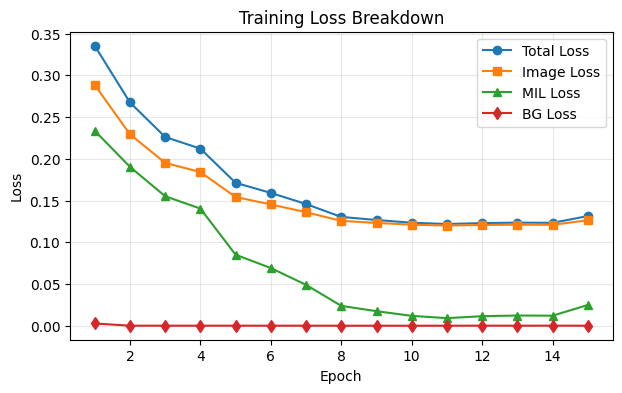

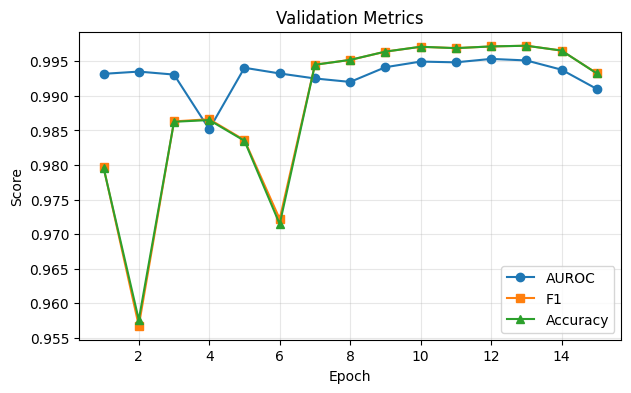

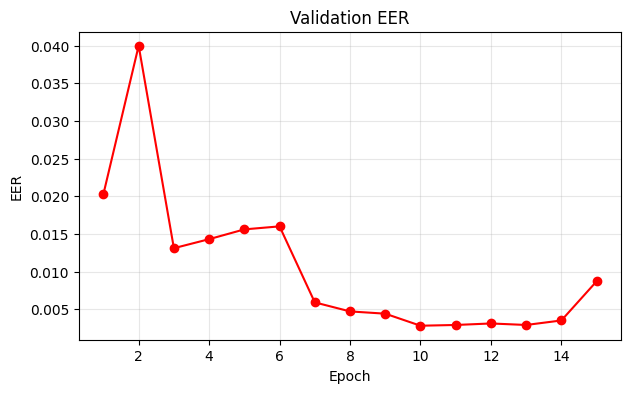

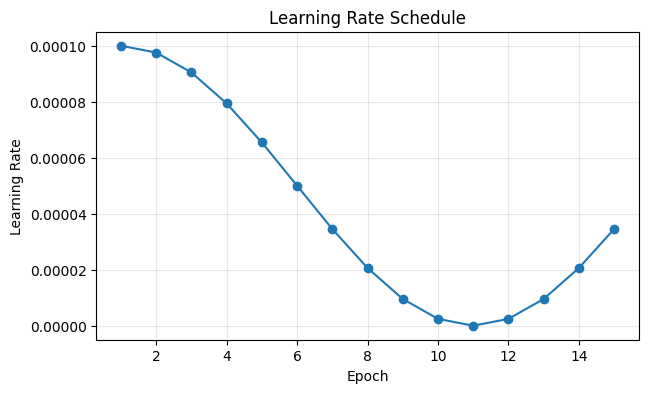

In [14]:
plot_loc_pretrain(
    train_loss_list,
    train_img_loss_list,
    train_mil_loss_list,
    train_bg_loss_list,
    val_auc_list,
    val_f1_list,
    val_acc_list,
    val_eer_list,
    lr_list
)


In [15]:
print("Final 140k Localisation Pretrain Results")
print(f"AUROC: {test_auc:.3f}")
print(f"F1-score: {test_f1:.3f}")
print(f"EER: {test_eer:.3f}")
print(f"Accuracy: {test_acc:.3f}")


Final 140k Localisation Pretrain Results
AUROC: 0.995
F1-score: 0.997
EER: 0.003
Accuracy: 0.997


## 8. Qualitative Localisation Analysis
This section visualises representative localisation examples from the 140k test set, including:
- correctly classified real images
- strong fake localisation examples
- correct fake predictions with weaker coverage
- failure cases

These examples help interpret where the model places manipulation evidence.


In [16]:
REGION_NAMES = [
    "full_face",
    "forehead_left", "forehead_center", "forehead_right",
    "left_eye", "right_eye",
    "left_eyebrow", "right_eyebrow",
    "nose_bridge", "nose_tip",
    "left_under_eye", "right_under_eye",
    "left_cheek_upper", "right_cheek_upper",
    "left_cheek_lower", "right_cheek_lower",
    "mouth_upper", "mouth_lower",
    "chin",
    "background"
]

def show_loc_examples(
    model,
    loader,
    class_to_idx,
    n_real_ok=2,
    n_best_fake=2,
    n_weak_fake=2,
    n_fail=2,
    alpha=0.85
):
    device = next(model.parameters()).device
    model.eval()
    fake_idx = class_to_idx["fake"]
    bg_idx = 19

    real_ok = []
    best_fake = []
    weak_fake = []
    fail = []

    with torch.no_grad():
        for x_rgb, x_raw, masks, lbls in loader:
            x_rgb = x_rgb.to(device)
            x_raw = x_raw.to(device)
            masks = masks.to(device)
            lbls = lbls.to(device)

            image_logits, region_logits, aux = model(
                x_rgb, x_raw, masks,
                return_regions=True,
                return_aux=True
            )

            probs = torch.softmax(image_logits, dim=1)
            preds = probs.argmax(dim=1)
            region_fake_all = torch.softmax(region_logits, dim=-1)[:, :, fake_idx].cpu().numpy()

            for i in range(x_rgb.size(0)):
                img = denorm_rgb_tensor(x_rgb[i])
                mask_np = masks[i].detach().cpu().numpy()
                region_fake = region_fake_all[i].copy()
                p_fake = float(probs[i, fake_idx].item())

                gt = int(lbls[i].item())
                pred = int(preds[i].item())

                region_fake[0] = 0.0
                region_fake[bg_idx] = 0.0

                heat = np.zeros((img.shape[0], img.shape[1]), dtype=np.float32)
                for r in range(len(region_fake)):
                    mask_r = cv2.resize(
                        mask_np[r].astype(np.float32),
                        (img.shape[1], img.shape[0]),
                        interpolation=cv2.INTER_LINEAR
                    )
                    heat += region_fake[r] * mask_r

                heat = cv2.GaussianBlur(heat, (21, 21), 0)
                heat = heat - heat.min()
                heat = heat / (heat.max() + 1e-6)
                gated_heat = heat * p_fake

                if p_fake < 0.45:
                    soft = np.zeros_like(gated_heat)
                else:
                    soft = gated_heat.copy()
                    thr = max(0.25, np.quantile(soft, 0.60))
                    soft[soft < thr] = 0.0

                    if soft.max() > 0:
                        soft /= soft.max()

                    soft = cv2.GaussianBlur(soft, (21, 21), 0)
                    soft = np.clip(soft, 0, 1)

                coverage = (soft > 0.10).mean() * 100.0

                item = {
                    "img": img,
                    "gt": gt,
                    "pred": pred,
                    "p_fake": p_fake,
                    "soft": soft,
                    "gated_heat": gated_heat,
                    "coverage": coverage,
                }

                if gt == pred and gt != fake_idx:
                    real_ok.append(item)

                elif gt == pred and gt == fake_idx:
                    best_score = 0.65 * p_fake + 0.35 * (coverage / 100.0)
                    weak_score = 0.80 * p_fake + 0.20 * (1.0 - coverage / 100.0)

                    item["best_score"] = best_score
                    item["weak_score"] = weak_score

                    best_fake.append(item)
                    weak_fake.append(item)

                else:
                    fail_margin = abs(p_fake - 0.5)
                    item["fail_margin"] = fail_margin
                    fail.append(item)

    real_ok = real_ok[:n_real_ok]
    best_fake = sorted(best_fake, key=lambda x: x["best_score"], reverse=True)[:n_best_fake]
    weak_fake = sorted(weak_fake, key=lambda x: x["weak_score"], reverse=True)[:n_weak_fake]
    fail = sorted(fail, key=lambda x: x["fail_margin"])[:n_fail]

    all_items = (
        [("Correct real", x) for x in real_ok] +
        [("Best fake localisation", x) for x in best_fake] +
        [("Weak fake coverage", x) for x in weak_fake] +
        [("Failure", x) for x in fail]
    )

    rows = len(all_items)
    fig, axes = plt.subplots(rows, 3, figsize=(12, 3.8 * rows))
    if rows == 1:
        axes = np.expand_dims(axes, 0)

    for i, (group_name, item) in enumerate(all_items):
        img = item["img"]
        soft = item["soft"]
        gated_heat = item["gated_heat"]
        p_fake = item["p_fake"]
        coverage = item["coverage"]

        overlay = img.copy()
        red = np.zeros_like(img)
        red[..., 0] = 1.0

        alpha_map = (alpha * soft)[..., None]
        overlay = (1 - alpha_map) * overlay + alpha_map * red
        overlay = np.clip(overlay, 0, 1)

        gt_name = "fake" if item["gt"] == fake_idx else "real"
        pred_name = "fake" if item["pred"] == fake_idx else "real"
        color = "#2ecc71" if item["gt"] == item["pred"] else "#e74c3c"

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(
            f"{group_name}\nGT={gt_name} | Pred={pred_name} | P(fake)={p_fake:.2f}",
            fontsize=9,
            color=color,
            fontweight="bold"
        )
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gated_heat, cmap="jet", vmin=0, vmax=1)
        axes[i, 1].set_title("Semantic region fake map")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(f"Predicted fake area | Coverage={coverage:.1f}%")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()



Showing localisation examples from 140k test set...


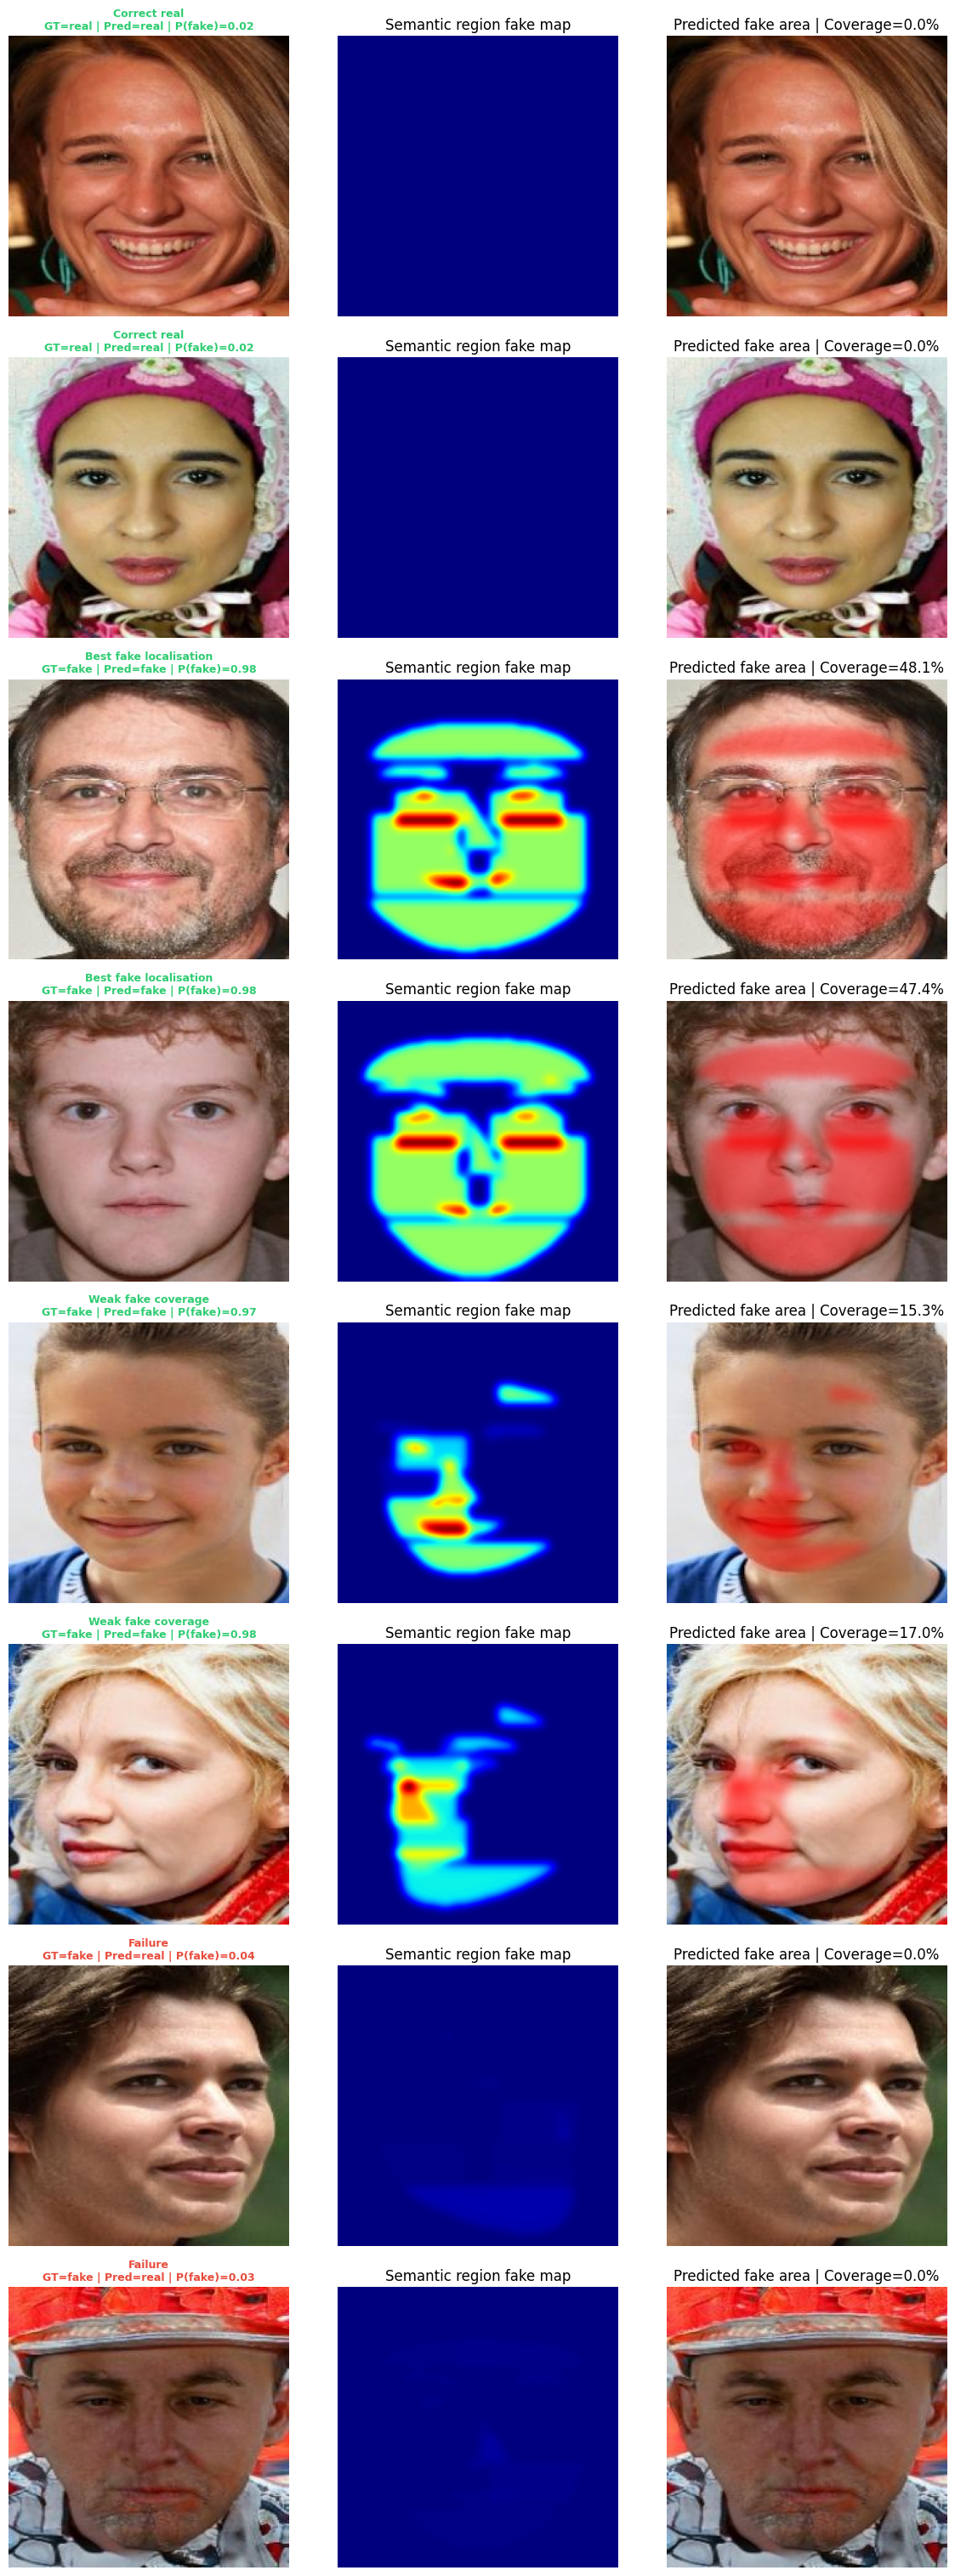

In [17]:
print("\nShowing localisation examples from 140k test set...")
show_loc_examples(
    model,
    testloader,
    class_to_idx,
    n_real_ok=2,
    n_best_fake=2,
    n_weak_fake=2,
    n_fail=2,
    alpha=0.85
)


## 9. Result Summary
The localisation pretraining stage achieved strong detection performance on the 140k test set while also producing meaningful semantic-region heatmaps.

This shows that semantic face regions can support interpretable localisation without sacrificing classification strength.


## 10. Conclusion
This notebook demonstrates that the semantic-region Stage 3 model can be successfully pretrained on the 140k aligned face dataset for both detection and localisation. In addition to strong quantitative performance, the model provides interpretable heatmaps that highlight suspicious facial regions associated with fake generation artifacts.
